# Student Performance Dataset - Relationship Between Variables

This notebook applies Exploratory Data Analysis (EDA) techniques to investigate relationships between variables in the Student Performance dataset.

The analysis focuses on:
- descriptive statistics
- grouped analysis
- variable relationships
- distributions
- correlation analysis
- visual interpretation

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 2. Load dataset

In [2]:
import os

dataset_file = "student_cleaned.csv"

if not os.path.exists(dataset_file):
    raise FileNotFoundError("Dataset file not found.")

df = pd.read_csv(dataset_file)

print(f"Loaded file: {dataset_file}")
print(f"Shape: {df.shape}")

display(df.head())

Loaded file: student_cleaned.csv
Shape: (6607, 11)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,84.2,Low,Low,Yes,7.4,50.3,Medium,Yes,1,54.3
1,19.7,63.6,Medium,High,Yes,6.7,83.1,Low,Yes,2,59.4
2,24.4,98.4,Medium,Medium,Yes,8.0,63.5,Medium,Yes,0,63.8
3,29.6,88.6,Medium,High,Yes,6.3,57.5,Medium,Yes,2,61.0
4,19.1,91.5,High,Medium,Yes,6.2,66.0,Medium,Yes,2,60.7


## 3. Dataset overview

The first step of EDA is understanding the structure of the dataset.
This includes:
- variable types
- missing values
- duplicated rows
- general dataset dimensions

In [3]:
print("Dataset information:")
df.info()

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicated rows:")
print(df.duplicated().sum())

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   float64
 1   Attendance                  6607 non-null   float64
 2   Parental_Involvement        6607 non-null   str    
 3   Access_to_Resources         6607 non-null   str    
 4   Extracurricular_Activities  6607 non-null   str    
 5   Sleep_Hours                 6607 non-null   float64
 6   Previous_Scores             6607 non-null   float64
 7   Motivation_Level            6607 non-null   str    
 8   Internet_Access             6607 non-null   str    
 9   Tutoring_Sessions           6607 non-null   int64  
 10  Final_Exam_Score            6607 non-null   float64
dtypes: float64(5), int64(1), str(5)
memory usage: 567.9 KB

Missing values:


,missing_values
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0



Duplicated rows:
0


## 4. Descriptive statistics

The describe() function provides:
- mean
- standard deviation
- quartiles
- minimum and maximum values

These statistics help understand central tendency and dispersion.

In [4]:
summary = df.describe().T

display(summary)

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,20.472726,5.988729,1.1,16.5,20.5,24.5,44.0
Attendance,6607.0,79.979068,11.547717,60.0,70.0,79.8,90.2,100.0
Sleep_Hours,6607.0,7.185273,1.290241,4.0,6.3,7.2,8.1,10.0
Previous_Scores,6607.0,74.716059,14.451962,50.0,62.1,74.6,87.4,100.0
Tutoring_Sessions,6607.0,1.488119,1.216175,0.0,1.0,1.0,2.0,8.0
Final_Exam_Score,6607.0,60.400333,8.739400,29.7,54.3,60.4,66.6,95.2


## 5. Frequency grouping (binning)

Hours studied are grouped into intervals (bins) to facilitate comparison between student profiles.

In [5]:
bins = [0, 10, 20, 30, 40, np.inf]
labels = ['0-9', '10-19', '20-29', '30-39', '40+']

df['Study_Group'] = pd.cut(
    df['Hours_Studied'],
    bins=bins,
    labels=labels,
    right=False
)

print(df['Study_Group'].value_counts().sort_index())

Study_Group
0-9       268
10-19    2796
20-29    3160
30-39     380
40+         3
Name: count, dtype: int64


## 6. Grouped analysis by study hours

This table summarizes:
- average final score
- average attendance
- average sleep hours
- average previous scores

for each study hour group.

In [6]:
study_summary = (
    df.groupby('Study_Group', observed=True)
    .agg(
        student_count=('Final_Exam_Score', 'count'),
        avg_exam_score=('Final_Exam_Score', 'mean'),
        avg_attendance=('Attendance', 'mean'),
        avg_sleep_hours=('Sleep_Hours', 'mean'),
        avg_previous_scores=('Previous_Scores', 'mean')
    )
    .reset_index()
)

display(study_summary)

,Study_Group,student_count,avg_exam_score,avg_attendance,avg_sleep_hours,avg_previous_scores
0,0-9,268,52.105224,80.164925,7.371642,73.313806
1,10-19,2796,57.815272,80.054971,7.203362,74.916702
2,20-29,3160,62.587753,79.912057,7.153354,74.733101
3,30-39,380,66.997632,79.834474,7.191316,74.126316
4,40+,3,70.966667,81.533333,6.533333,69.733333


## 7. Relationship between motivation and performance

This grouped analysis compares motivation levels with academic performance.

In [7]:
motivation_summary = (
    df.groupby('Motivation_Level', observed=True)
    .agg(
        avg_exam_score=('Final_Exam_Score', 'mean'),
        avg_hours_studied=('Hours_Studied', 'mean'),
        avg_attendance=('Attendance', 'mean')
    )
    .reset_index()
)

display(motivation_summary)

,Motivation_Level,avg_exam_score,avg_hours_studied,avg_attendance
0,High,63.938473,20.614521,79.822380
1,Low,57.541645,20.390822,80.042493
2,Medium,60.595747,20.462374,80.005582


## 8. Histogram - Final exam score distribution

Histograms help identify:
- central tendency
- dispersion
- skewness
- concentration of observations

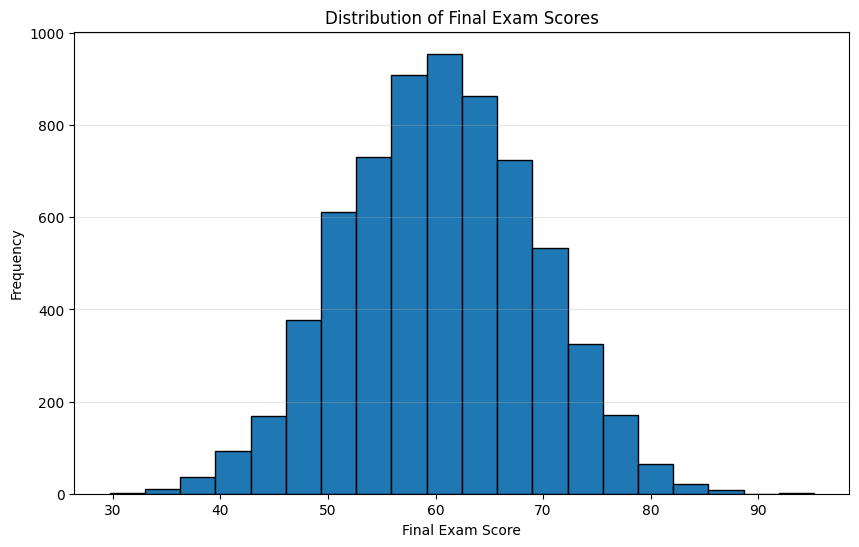

In [8]:
plt.figure(figsize=(10,6))

plt.hist(
    df['Final_Exam_Score'].dropna(),
    bins=20,
    edgecolor='black'
)

plt.title('Distribution of Final Exam Scores')
plt.xlabel('Final Exam Score')
plt.ylabel('Frequency')

plt.grid(axis='y', alpha=0.3)
plt.show()

## 9. Bar plot - Average score by study group

This visualization compares the average final exam score across study hour intervals.

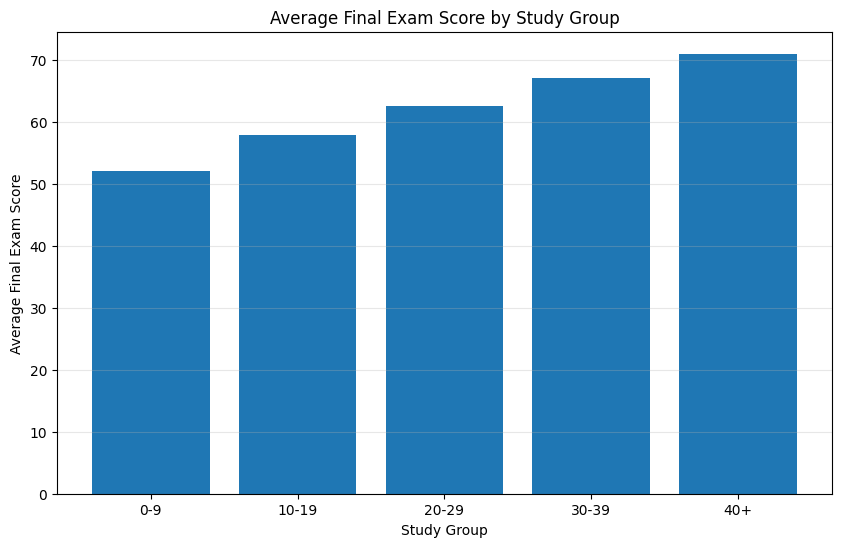

In [9]:
plt.figure(figsize=(10,6))

plt.bar(
    study_summary['Study_Group'].astype(str),
    study_summary['avg_exam_score']
)

plt.title('Average Final Exam Score by Study Group')
plt.xlabel('Study Group')
plt.ylabel('Average Final Exam Score')

plt.grid(axis='y', alpha=0.3)
plt.show()

## 10. Scatter plot - Study hours vs final exam score

Scatter plots help identify:
- relationships between variables
- trends
- possible correlations
- outliers

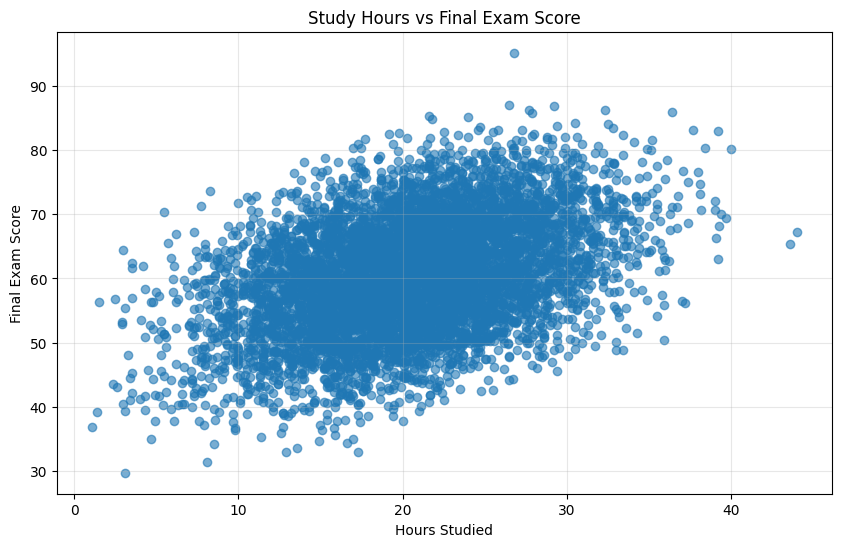

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Hours_Studied'],
    df['Final_Exam_Score'],
    alpha=0.6
)

plt.title('Study Hours vs Final Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Final Exam Score')

plt.grid(alpha=0.3)
plt.show()

## 11. Correlation analysis

Correlation measures how variables vary together.

Values close to:
- 1 indicate strong positive correlation
- -1 indicate strong negative correlation
- 0 indicate weak or no correlation

In [11]:
correlation_matrix = df.corr(numeric_only=True)

display(correlation_matrix)

print("\nCorrelation with Final Exam Score:")

display(
    correlation_matrix['Final_Exam_Score']
    .sort_values(ascending=False)
    .to_frame('correlation_with_final_exam_score')
)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Final_Exam_Score
Hours_Studied,1.000000,-0.010350,-0.028068,-0.003614,-0.002372,0.409850
Attendance,-0.010350,1.000000,0.018120,-0.002012,-0.012405,0.266152
Sleep_Hours,-0.028068,0.018120,1.000000,0.015483,-0.004081,-0.012736
Previous_Scores,-0.003614,-0.002012,0.015483,1.000000,0.003964,0.653388
Tutoring_Sessions,-0.002372,-0.012405,-0.004081,0.003964,1.000000,0.207310
Final_Exam_Score,0.409850,0.266152,-0.012736,0.653388,0.207310,1.000000



Correlation with Final Exam Score:


,correlation_with_final_exam_score
Final_Exam_Score,1.000000
Previous_Scores,0.653388
Hours_Studied,0.409850
Attendance,0.266152
Tutoring_Sessions,0.207310
Sleep_Hours,-0.012736


## 12. Final observations

The exploratory analysis identified relationships between study habits and student performance.

The results suggest that variables such as:
- study hours
- attendance
- previous scores
- motivation

may influence final academic performance.

The notebook demonstrates how EDA techniques can support interpretation and understanding of relationships between variables before predictive modeling.